In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

/Users/anantmittal/Code/ssec/Rubin-RAG/.pixi/envs/default/lib/python3.11/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange


In [2]:
# Load the Excel File
file_path = '../data/lsst_forum_responses.xlsx'
lsst_forum_responses_df = pd.read_excel(file_path)

In [3]:
lsst_forum_responses_df.head()

,category_id,context,question,question_author,question_date,answer,answer_author,answer_date,primary_group_name,flair_name,flair_url,moderator,admin,staff,is_accepted_answer
0,6,RubinObservatory.org site issue with Chrome on...,"<p>Hello, Rubin website team-</p>\n<p>This is ...",229,2025-02-06,<p>I think you pinpointed the problem—once a p...,TomLoredo,2025-02-07,NaN,NaN,NaN,False,False,False,False
1,6,RubinObservatory.org site issue with Chrome on...,"<p>Hello, Rubin website team-</p>\n<p>This is ...",229,2025-02-06,<p>Yes! It turned out that this was a known is...,MelissaGraham,2025-02-07,LSSTDM,CST,hands-helping,True,True,True,False
2,6,RubinObservatory.org site issue with Chrome on...,"<p>Hello, Rubin website team-</p>\n<p>This is ...",229,2025-02-06,"<p>Hi <a class=""mention"" href=""/u/tomloredo"">@...",MelissaGraham,2025-02-06,LSSTDM,CST,hands-helping,True,True,True,True
3,59,"Rubin Science Assembly, Thu Feb 6 2025: Lookin...","<p><strong>Date:</strong> Thu Feb 6 2025, 9:00...",175,2025-02-04,"<p>Slides:</p>\n<p><a class=""attachment"" href=...",MelissaGraham,2025-02-06,LSSTDM,CST,hands-helping,True,True,True,False
4,60,UK IDAC offline for maintenance during 4th--5t...,<p>Apologies for short notice. Due to planned ...,245,2025-02-04,<p>The UK IDAC is now back online. Apologies f...,george_beckett,2025-02-06,NaN,NaN,NaN,True,False,True,True


In [4]:
print("Shape of the data:", lsst_forum_responses_df.shape)

Shape of the data: (8029, 15)


In [5]:
lsst_forum_responses_df.columns

Index(['category_id', 'context', 'question', 'question_author',
       'question_date', 'answer', 'answer_author', 'answer_date',
       'primary_group_name', 'flair_name', 'flair_url', 'moderator', 'admin',
       'staff', 'is_accepted_answer'],
      dtype='object')

In [6]:
print("\nData Types:\n", lsst_forum_responses_df.dtypes)


Data Types:
 category_id                    int64
context                       object
question                      object
question_author                int64
question_date         datetime64[ns]
answer                        object
answer_author                 object
answer_date           datetime64[ns]
primary_group_name            object
flair_name                    object
flair_url                     object
moderator                       bool
admin                           bool
staff                           bool
is_accepted_answer              bool
dtype: object


In [7]:
print("Missing Values:\n", lsst_forum_responses_df.isnull().sum())

Missing Values:
 category_id              0
context                  0
question                 5
question_author          0
question_date            0
answer                  53
answer_author            0
answer_date              0
primary_group_name    2951
flair_name            2908
flair_url             7086
moderator                0
admin                    0
staff                    0
is_accepted_answer       0
dtype: int64


In [8]:
# Load the Excel File
file_path = '../data/lsst_forum_responses_clean.xlsx'
lsst_forum_responses_clean_df = pd.read_excel(file_path)

In [9]:
lsst_forum_responses_clean_df.head()

,category_id,context,question,question_author,question_date,answer,answer_author,answer_date,primary_group_name,flair_name,flair_url,moderator,admin,staff,is_accepted_answer
0,6,RubinObservatory.org site issue with Chrome on...,"Hello, Rubin website team- \n This is to repor...",229,2025-02-06,I think you pinpointed the problem—once a page...,TomLoredo,2025-02-07,NaN,NaN,NaN,False,False,False,False
1,6,RubinObservatory.org site issue with Chrome on...,"Hello, Rubin website team- \n This is to repor...",229,2025-02-06,Yes! It turned out that this was a known issue...,MelissaGraham,2025-02-07,LSSTDM,CST,hands-helping,True,True,True,False
2,6,RubinObservatory.org site issue with Chrome on...,"Hello, Rubin website team- \n This is to repor...",229,2025-02-06,"Hi @TomLoredo , thanks for checking out the ...",MelissaGraham,2025-02-06,LSSTDM,CST,hands-helping,True,True,True,True
3,59,"Rubin Science Assembly, Thu Feb 6 2025: Lookin...","Date: Thu Feb 6 2025, 9:00-10:00am PST ( 2025...",175,2025-02-04,Slides: \n Rubin_Science_Assembly_2025-02-06.p...,MelissaGraham,2025-02-06,LSSTDM,CST,hands-helping,True,True,True,False
4,60,UK IDAC offline for maintenance during 4th--5t...,Apologies for short notice. Due to planned mai...,245,2025-02-04,The UK IDAC is now back online. Apologies for ...,george_beckett,2025-02-06,NaN,NaN,NaN,True,False,True,True


In [10]:
lsst_forum_responses_clean_df.shape

(8029, 15)

> The only difference between `lsst_forum_responses` and `lsst_forum_responses_clean` seems to be that `lsst_forum_responses_clean` file does not have HTML tags in `question` and `answer` column.
>
> We will proceed with lsst_forum_responses_clean_df dataframe.

In [11]:
lsst_forum_responses_clean_df.dtypes

category_id                    int64
context                       object
question                      object
question_author                int64
question_date         datetime64[ns]
answer                        object
answer_author                 object
answer_date           datetime64[ns]
primary_group_name            object
flair_name                    object
flair_url                     object
moderator                       bool
admin                           bool
staff                           bool
is_accepted_answer              bool
dtype: object

In [12]:
lsst_forum_responses_clean_df['answer_str'] = lsst_forum_responses_clean_df['answer'].astype(str)
lsst_forum_responses_clean_df['question_str'] = lsst_forum_responses_clean_df['question'].astype(str)

In [13]:
lsst_forum_responses_clean_df['answer_length'] = lsst_forum_responses_clean_df['answer_str'].apply(lambda x: len(x.split()))
lsst_forum_responses_clean_df['question_length'] = lsst_forum_responses_clean_df['question_str'].apply(lambda x: len(x.split()))
lsst_forum_responses_clean_df.columns.to_list()

['category_id',
 'context',
 'question',
 'question_author',
 'question_date',
 'answer',
 'answer_author',
 'answer_date',
 'primary_group_name',
 'flair_name',
 'flair_url',
 'moderator',
 'admin',
 'staff',
 'is_accepted_answer',
 'answer_str',
 'question_str',
 'answer_length',
 'question_length']

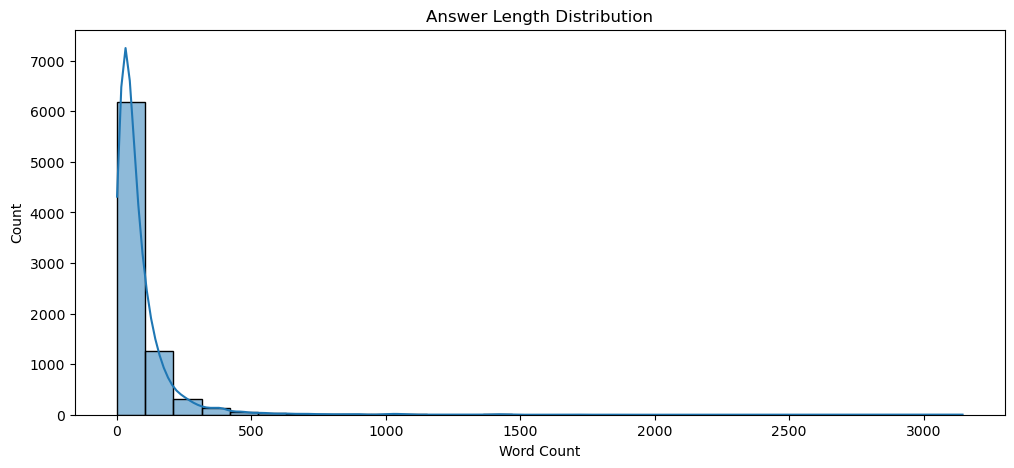

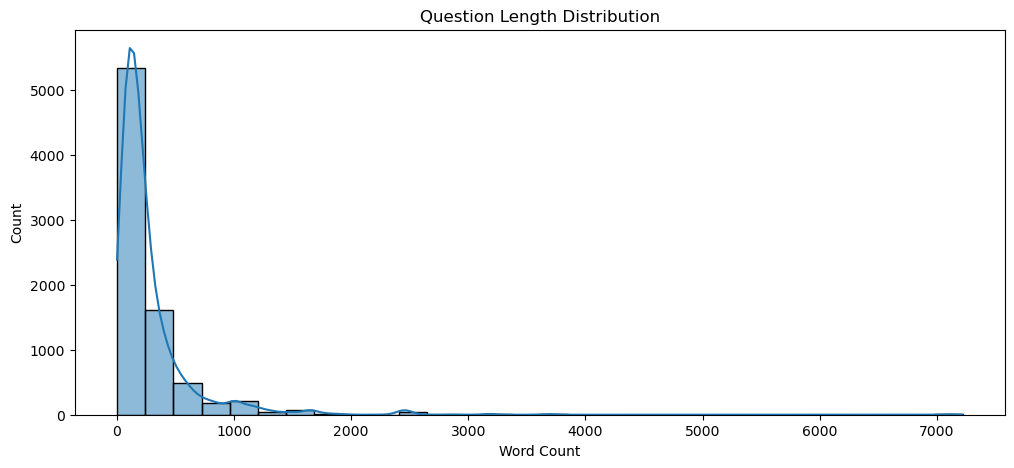

In [14]:
# Text Lengths Viz
plt.figure(figsize=(12, 5))
sns.histplot(lsst_forum_responses_clean_df['answer_length'], bins=30, kde=True)
plt.title('Answer Length Distribution')
plt.xlabel('Word Count')
plt.show()

plt.figure(figsize=(12, 5))
sns.histplot(lsst_forum_responses_clean_df['question_length'], bins=30, kde=True)
plt.title('Question Length Distribution')
plt.xlabel('Word Count')
plt.show()

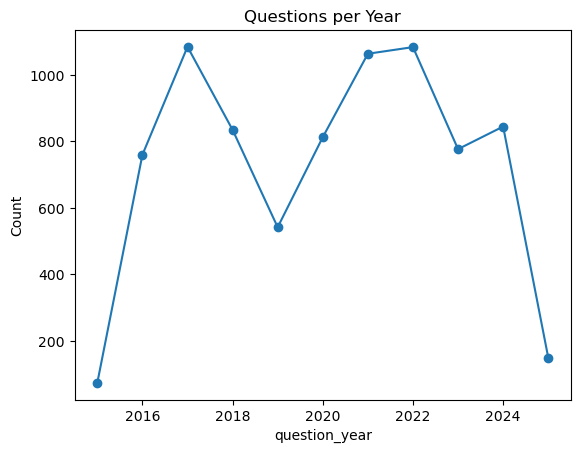

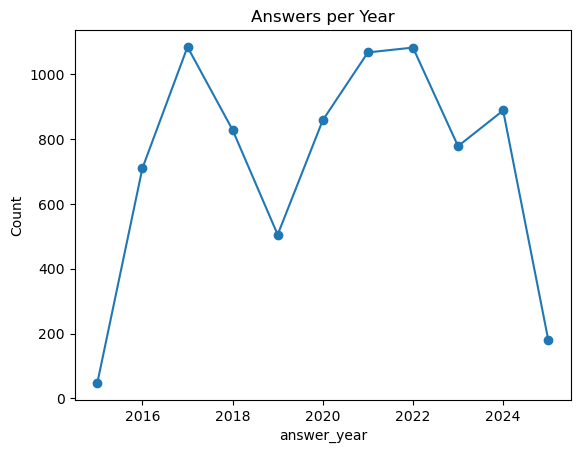

In [15]:
# Yearly Trends
lsst_forum_responses_clean_df['question_year'] = lsst_forum_responses_clean_df['question_date'].dt.year
lsst_forum_responses_clean_df['answer_year'] = lsst_forum_responses_clean_df['answer_date'].dt.year

questions_by_year = lsst_forum_responses_clean_df.groupby('question_year').size()
answers_by_year = lsst_forum_responses_clean_df.groupby('answer_year').size()

questions_by_year.plot(title='Questions per Year', marker='o')
plt.ylabel('Count')
plt.show()

answers_by_year.plot(title='Answers per Year', marker='o')
plt.ylabel('Count')
plt.show()


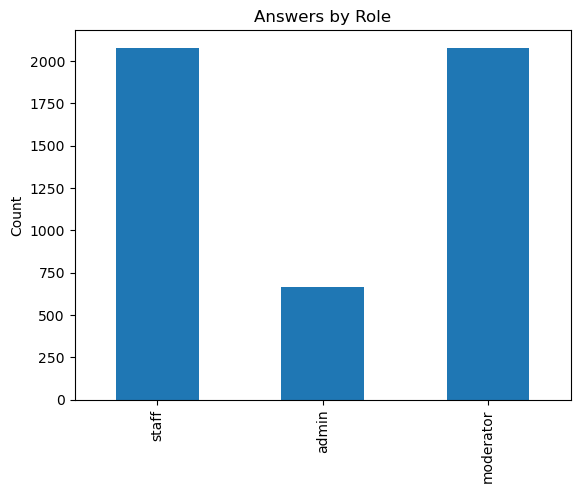

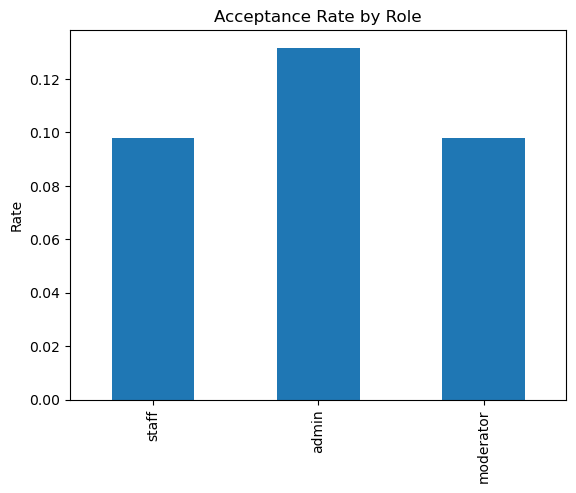

In [16]:
# Role based insights
role_cols = ['staff', 'admin', 'moderator']

answer_counts_by_role = {r: lsst_forum_responses_clean_df[lsst_forum_responses_clean_df[r]]['answer'].count() for r in role_cols}
acceptance_by_role = {r: lsst_forum_responses_clean_df[lsst_forum_responses_clean_df[r]]['is_accepted_answer'].mean() for r in role_cols}

pd.Series(answer_counts_by_role).plot(kind='bar', title='Answers by Role')
plt.ylabel('Count')
plt.show()

pd.Series(acceptance_by_role).plot(kind='bar', title='Acceptance Rate by Role')
plt.ylabel('Rate')
plt.show()

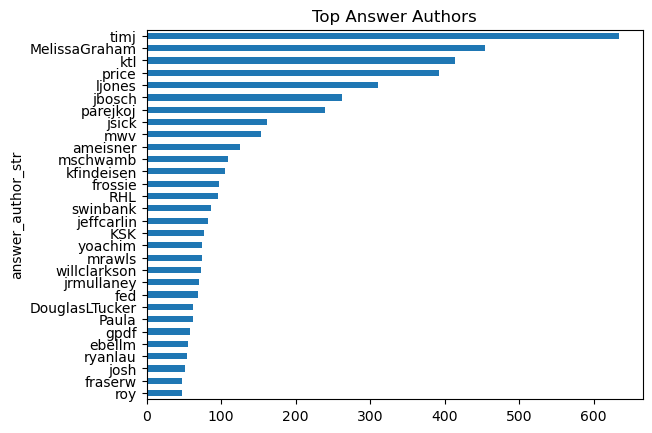

In [17]:
# top contributors
lsst_forum_responses_clean_df['question_author_str'] = lsst_forum_responses_clean_df['question_author'].astype(str)
lsst_forum_responses_clean_df['answer_author_str'] = lsst_forum_responses_clean_df['answer_author'].astype(str)

lsst_forum_responses_clean_df['answer_author_str'].value_counts().head(30).plot(kind='barh', title='Top Answer Authors')
plt.gca().invert_yaxis()
plt.show()

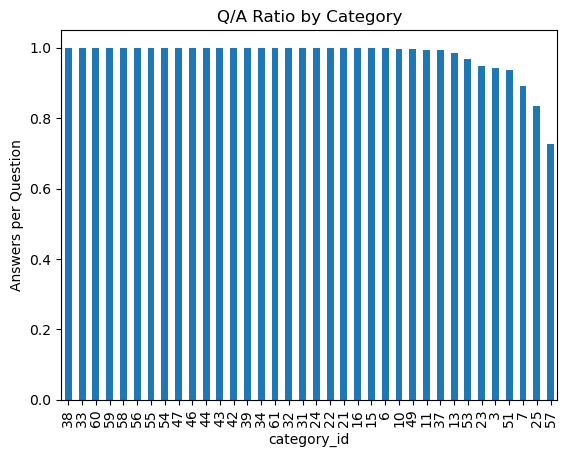

In [18]:
# Q/A Ratio 
qa_ratio = lsst_forum_responses_clean_df.groupby('category_id').agg(
    questions=('question', 'count'),
    answers=('answer', lambda x: x.notna().sum())
)
qa_ratio['qa_ratio'] = qa_ratio['answers'] / qa_ratio['questions']
qa_ratio['qa_ratio'].sort_values(ascending=False).plot(kind='bar', title='Q/A Ratio by Category')
plt.ylabel('Answers per Question')
plt.show()



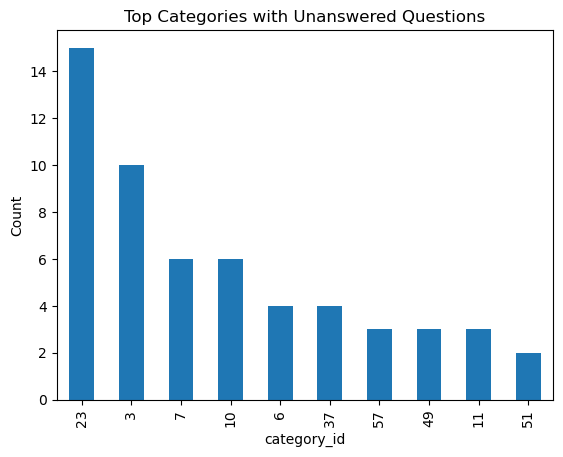

In [19]:
# Unanswered Questions
unanswered = lsst_forum_responses_clean_df[lsst_forum_responses_clean_df['answer'].isnull()]
unanswered['category_id'].value_counts().head(10).plot(kind='bar', title='Top Categories with Unanswered Questions')
plt.ylabel('Count')
plt.show()

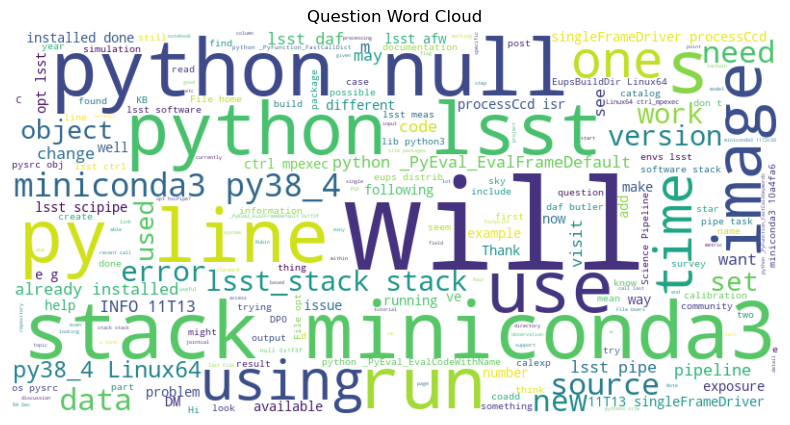

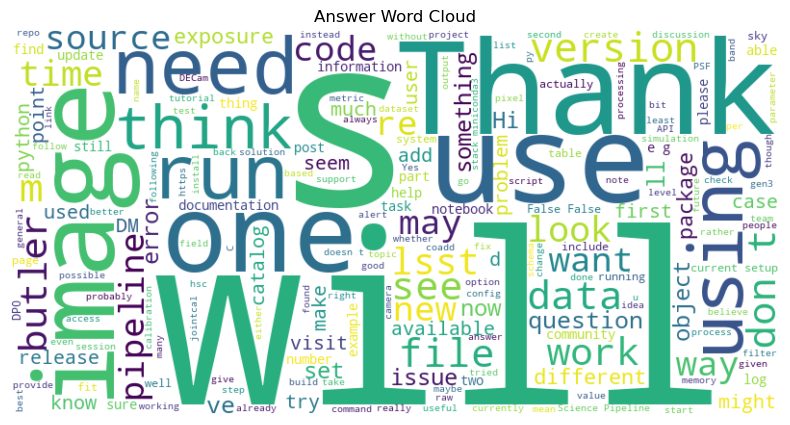

In [20]:
# Word Clouds 
question_sample = " ".join(lsst_forum_responses_clean_df['question_str'].dropna().sample(1000, random_state=42))
answer_sample = " ".join(lsst_forum_responses_clean_df['answer_str'].dropna().sample(1000, random_state=42))

q_wc = WordCloud(width=800, height=400, background_color='white').generate(question_sample)
a_wc = WordCloud(width=800, height=400, background_color='white').generate(answer_sample)

plt.figure(figsize=(10, 5))
plt.imshow(q_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Question Word Cloud')
plt.show()

plt.figure(figsize=(10, 5))
plt.imshow(a_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Answer Word Cloud')
plt.show()